# Run matched filter on EnMAP product

Author: Gonzalo Mateo-García

Example of using EnMAP reader from [georeader](https://spaceml-org.github.io/georeader/enmap_with_cloudsen12/).

The Window-Wide Matched Filter is proposed in:
>  J. Roger, L. Guanter, J. Gorroño, and I. Irakulis-Loitxate, “Exploiting the entire near-infrared spectral range to improve the detection of methane plumes with high-resolution imaging spectrometers,” Atmospheric Measurement Techniques, vol. 17, no. 4, pp. 1333–1346, Feb. 2024, doi: [10.5194/amt-17-1333-2024](https://doi.org/10.5194/amt-17-1333-2024).

## Download EnMAP image from UNEP IMEO Cloud Storage

This requires the `adlfs` package:

```
pip install adlfs
```

In [1]:
import os

SAS_TOKEN = ""
AZURE_STORAGE_ACCOUNT=""
CONTAINER = ""

In [2]:
import adlfs
fs = adlfs.AzureBlobFileSystem(account_name=AZURE_STORAGE_ACCOUNT, sas_token=SAS_TOKEN, container=CONTAINER)

In [3]:
folder_dest = "EnMAP"
os.makedirs(folder_dest, exist_ok=True)
PRODUCT_FOLDERS = {
    "SPECTRAL_IMAGE_SWIR": "swir",
    "QL_QUALITY_CLOUDSHADOW": "ql/cloudshadow",
    "QL_PIXELMASK_SWIR": "ql/pixelmask_swir",
    "QL_QUALITY_CIRRUS": "ql/cirrus",
    "QL_QUALITY_SNOW": "ql/snow",
    "QL_PIXELMASK_VNIR": "ql/pixelmask_vnir",
    "QL_QUALITY_TESTFLAGS_SWIR": "ql/testflags_swir",
    "QL_QUALITY_HAZE": "ql/haze",
    "QL_QUALITY_TESTFLAGS_VNIR": "ql/testflags_vnir",
    "QL_QUALITY_CLASSES": "ql/classes",
    "QL_SWIR": "ql/swir",
    "QL_QUALITY_CLOUD": "ql/cloud",
    "QL_VNIR": "ql/vnir",
    "SPECTRAL_IMAGE_VNIR": "vnir",
}

tile = "ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z"

folder_dest_tile = os.path.join(folder_dest, tile)
os.makedirs(folder_dest, exist_ok=True)

# Copy metadata
path_metadata_dst = os.path.join(folder_dest_tile, f"{tile}-METADATA.XML")
if not os.path.exists(path_metadata_dst):
    path_metadata = f"az://{CONTAINER}/EnMAP/metadata/{tile}.xml"
    if not fs.exists(path_metadata):
        raise FileNotFoundError(f"File {path_metadata} does not exist")
    
    fs.get(path_metadata, path_metadata_dst)

# Download TIF files
for extension, folder in PRODUCT_FOLDERS.items():
    path = f"az://{CONTAINER}/EnMAP/{folder}/{tile}.tif"
    path_dst = os.path.join(folder_dest_tile, f"{tile}-{extension}.TIF")
    if os.path.exists(path_dst):
        continue
    if not fs.exists(path):
        print(f"File {path} not found skipping")
        continue
    print(f"Downloading file {path}...")
    fs.get(path, path_dst)
    

In [11]:
!tree {folder_dest_tile}

EnMAP/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-METADATA.XML
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_PIXELMASK_SWIR.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_PIXELMASK_VNIR.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_CIRRUS.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_CLASSES.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_CLOUDSHADOW.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_CLOUD.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_HAZE.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_SNOW.TIF
├── ENMAP01-____L1

## Load image

In [4]:
from georeader.readers import enmap

rst = enmap.EnMAP(xml_file=path_metadata_dst,by_folder=False)
rst

/home/gonzalo/git/mars_mf/.venv/lib/python3.10/site-packages/georeader/reflectance.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



        File: EnMAP/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-METADATA.XML
        Bounds: (50.51780770053884, 25.848010435158116, 50.87829864231832, 26.16557822198474)
        Time: 2025-08-20 07:51:56.417253+00:00
        Spatial shape (height, width): (1024, 1000)
        VNIR Range: (np.float64(411.42039), np.float64(1003.9755)) nbands: 91 
        SWIR Range: (np.float64(892.78475), np.float64(2452.4581000000003)) nbands: 133
        

## Run WMF retrieval on EMIT product

Run wide matched filter retrieval based on the work of [Roger et al. 2024](https://doi.org/10.5194/amt-17-1333-2024).

In [5]:
import logging

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

from mars_mf.prismaenmap import retrieval_upv_prisma_enmap

cube = retrieval_upv_prisma_enmap.MF_sunglint_combo_enmap(rst,logger=logger)

INFO:__main__:Running WMF in wavelength range: 941.218 - 2422.78
INFO:__main__:Running MF2100 in wavelength range: 2104.59 - 2400.0


## Reproject to UTM and apply RPCS

In [6]:
import georeader
from georeader import read
import numpy as np
crs = georeader.get_utm_epsg(cube.footprint(crs="EPSG:4326").centroid)

cube_crs = read.read_rpcs(
    cube.values.astype(np.float32),
    rpcs=rst.rpcs_swir,
    dst_crs=crs,
    resolution_dst_crs=30,
    fill_value_default=cube.fill_value_default,
)
cube_crs

 
         Transform: | 30.00, 0.00, 451693.10|
| 0.00,-30.00, 2893241.74|
| 0.00, 0.00, 1.00|
         Shape: (7, 1155, 1201)
         Resolution: (30.0, 30.0)
         Bounds: (451693.09669864795, 2858591.7388603096, 487723.09669864795, 2893241.7388603096)
         CRS: EPSG:32639
         fill_value_default: -1
        

In [7]:
retrieval_upv_prisma_enmap.BAND_NAMES_COMBO

['Rad_out',
 'MF(2100-2400)',
 'WWMF(1000-2400)',
 'MF-Combo',
 'MF(2100-2400)FILTERED',
 'WWMF(1000-2400)FILTERED',
 'MF-Combo-Filtered']

In [8]:
rgb = rst.load_rgb(as_reflectance=True, dst_crs=crs, apply_rpcs=True)
rgb

 
         Transform: | 29.00, 0.00, 451783.53|
| 0.00,-29.00, 2893793.80|
| 0.00, 0.00, 1.00|
         Shape: (3, 1194, 1242)
         Resolution: (29.000371667265426, 29.000371667090803)
         Bounds: (451783.5260194169, 2859167.3566287113, 487801.9876301346, 2893793.800399401)
         CRS: EPSG:32639
         fill_value_default: 0.0
        

## Plot results

<Axes: title={'center': 'WWMF $\\Delta X$CH$_4$ [ppm]'}>

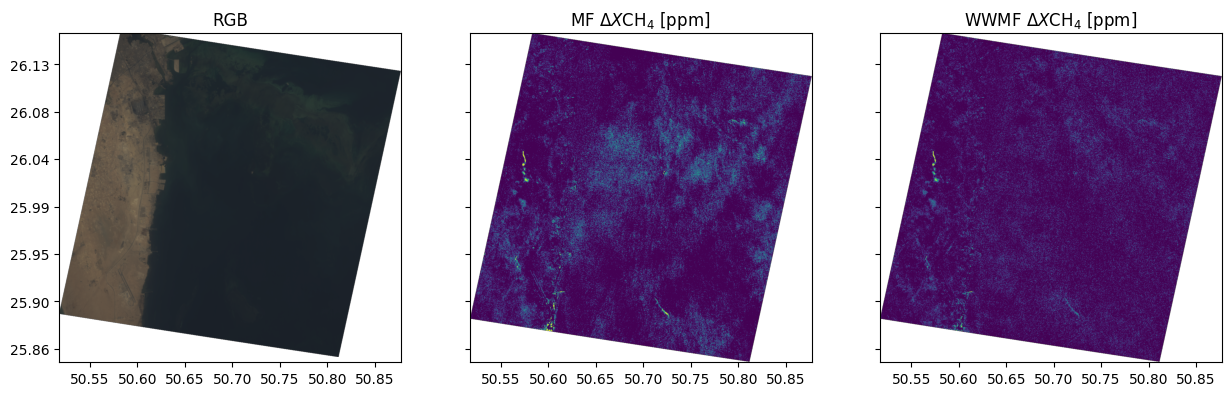

In [10]:
from georeader import plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True)
plot.show(rgb, ax=ax[0], mask=True, title="RGB")

mf = cube_crs.isel({"band": 1})
plot.show(mf, ax=ax[1], vmin=0, vmax=.3, title= "MF $\Delta X$CH$_4$ [ppm]", mask=True)
wmf = cube_crs.isel({"band": 2})
plot.show(wmf, ax=ax[2], vmin=0, vmax=.3, title= "WWMF $\Delta X$CH$_4$ [ppm]", mask=True)

The mars_mf package and tutorials are released under a [Creative Commons non-commercial Share-Alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt). For using the codes in comercial pipelines written consent by the authors must be provided.

 If you find this work useful please cite:

```
@Article{roger_2024,
    AUTHOR = {Roger, J. and Guanter, L. and Gorroño, J. and Irakulis-Loitxate, I.},
    TITLE = {Exploiting the entire near-infrared spectral range to improve the detection of methane plumes with high-resolution imaging spectrometers},
    JOURNAL = {Atmospheric Measurement Techniques},
    VOLUME = {17},
    YEAR = {2024},
    NUMBER = {4},
    PAGES = {1333--1346},
    URL = {https://amt.copernicus.org/articles/17/1333/2024/},
    DOI = {10.5194/amt-17-1333-2024}
}
```